In [ ]:
pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 53.3 MB/s eta 0:00:00


# 2 Level Atom

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


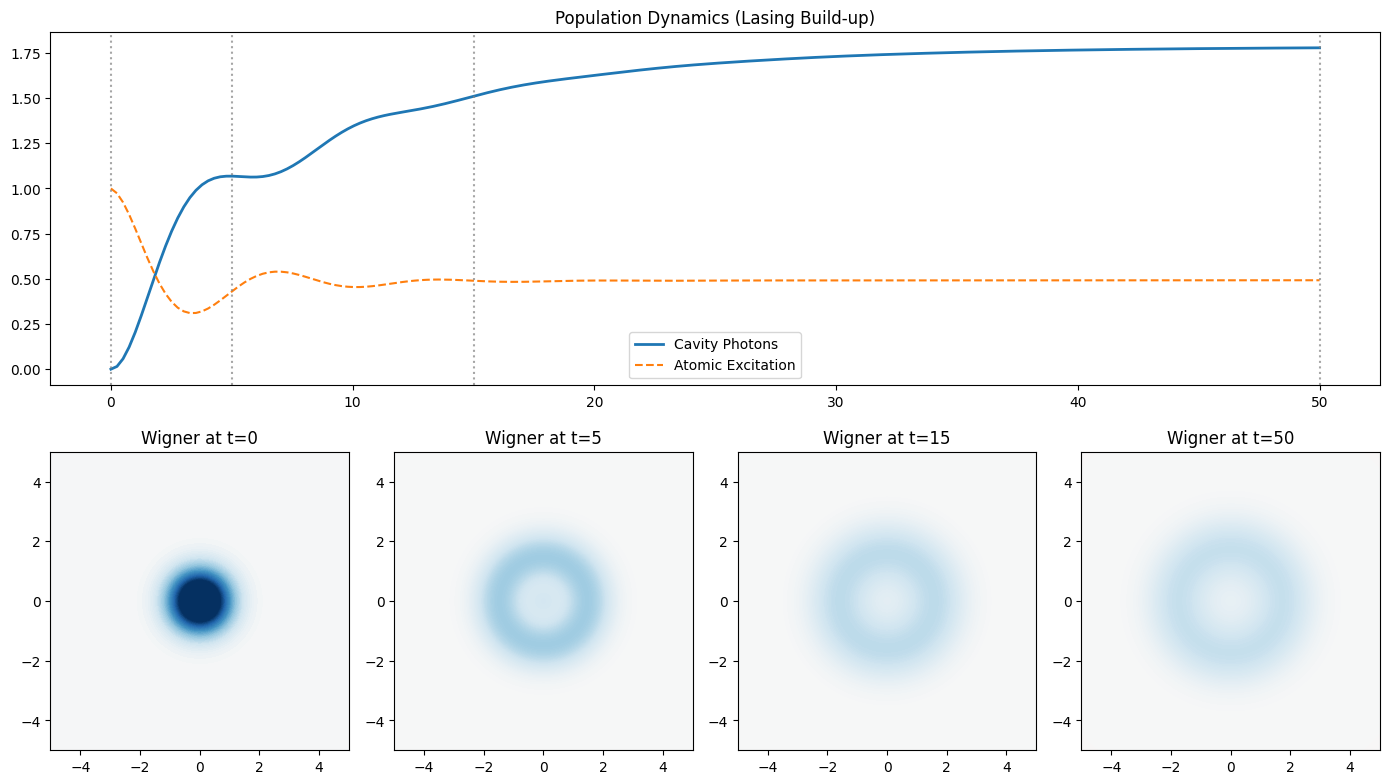

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (basis, tensor, destroy, mesolve, wigner,
                   qeye, sigmap, sigmam, ptrace)

# 1. System Parameters for Lasing
N = 25              # Cavity Fock states (must be > expected photon number)
g = 0.5             # Atom-cavity coupling strength
kappa = 0.1         # Cavity decay rate
gamma = 0.05        # Atomic decay rate
pump = 0.4          # Incoherent pumping rate (sigma-plus) to create gain

# 2. Operators and Hamiltonian
a = tensor(destroy(N), qeye(2))
sm = tensor(qeye(N), sigmam())
sp = tensor(qeye(N), sigmap())
H = g * (a.dag() * sm + a * sp) # Interaction Hamiltonian

# 3. Collapse Operators (Decay and Pumping)
# The pump [np.sqrt(pump) * sp] drives the atom to the excited state
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm, np.sqrt(pump) * sp]

# 4. Simulation Time
times = np.linspace(0, 50, 200)
# Select 4 specific times to capture the evolution: Initial, Rising, and Steady-State
plot_times = [0, 5, 15, 50]

# 5. Solve Dynamics
# We track photon number <a*a> and atomic excitation <sp*sm>
result = mesolve(H, tensor(basis(N, 0), basis(2, 0)), times, c_ops, [a.dag() * a, sp * sm])

# 6. Plotting Results
fig = plt.figure(figsize=(14, 8))
xvec = np.linspace(-5, 5, 150)

# Plot Population Dynamics
ax_dyn = plt.subplot2grid((2, 4), (0, 0), colspan=4)
ax_dyn.plot(times, result.expect[0], label="Cavity Photons", lw=2)
ax_dyn.plot(times, result.expect[1], label="Atomic Excitation", ls="--")
for t in plot_times:
    ax_dyn.axvline(t, color='gray', linestyle=':', alpha=0.7)
ax_dyn.set_title("Population Dynamics (Lasing Build-up)")
ax_dyn.legend()

# Plot Wigner Functions at 4 snapshots
states_data = mesolve(H, tensor(basis(N, 0), basis(2, 0)), plot_times, c_ops).states
for i, state in enumerate(states_data):
    rho_cavity = ptrace(state, 0) # Trace out the atom to get cavity state
    W = wigner(rho_cavity, xvec, xvec)

    ax = plt.subplot2grid((2, 4), (1, i))
    cont = ax.contourf(xvec, xvec, W, 100, cmap='RdBu', vmin=-0.2, vmax=0.2)
    ax.set_title(f"Wigner at t={plot_times[i]}")
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 3-Level Atom (Updated for paper)

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


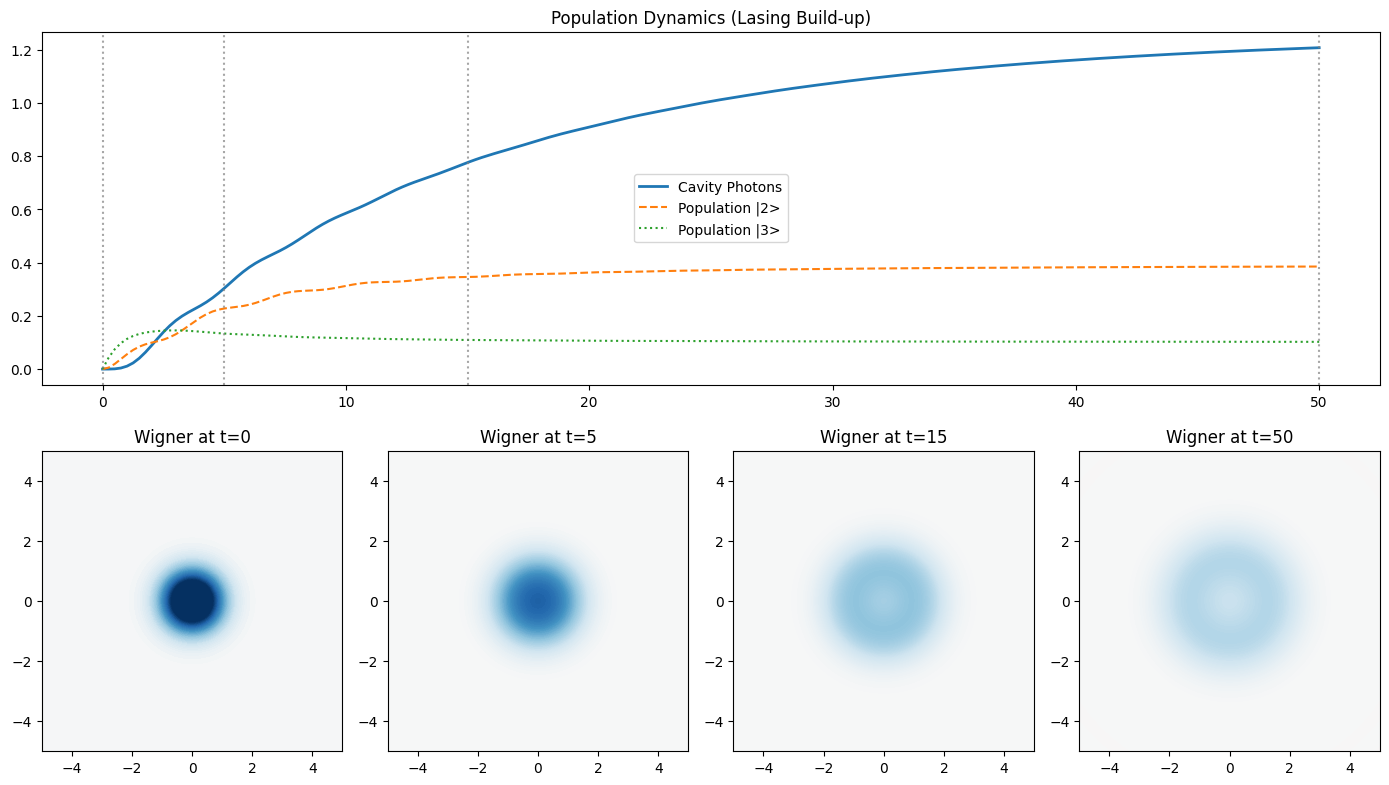

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (basis, tensor, destroy, mesolve, wigner,
                   qeye, ptrace)

# 1. System Parameters for Lasing
N = 30
g = 1
kappa = 0.05
gamma12 = 0.1
gamma23 = 1.0
Gamma = 0.2

# 2. Operators and Hamiltonian
a = tensor(destroy(N), qeye(3))

b1 = basis(3, 0)   # |1>
b2 = basis(3, 1)   # |2>
b3 = basis(3, 2)   # |3>

sm = tensor(qeye(N), b1 * b2.dag())   # |2> -> |1|
sp = tensor(qeye(N), b2 * b1.dag())   # |1> -> |2|
pump_op = tensor(qeye(N), b3 * b1.dag())   # |1> -> |3|
decay_23 = tensor(qeye(N), b2 * b3.dag())  # |3> -> |2|

H = g * (a.dag() * sm + a * sp)

# 3. Collapse Operators
c_ops = [
    np.sqrt(kappa) * a,
    np.sqrt(gamma12) * sm,
    np.sqrt(gamma23) * decay_23,
    np.sqrt(Gamma) * pump_op
]

# 4. Simulation Time
times = np.linspace(0, 50, 200)
plot_times = [0, 5, 15, 50]

# 5. Initial State
psi0 = tensor(basis(N, 0), basis(3, 0))

# 6. Solve Dynamics
result = mesolve(
    H,
    psi0,
    times,
    c_ops,
    [
        a.dag() * a,
        tensor(qeye(N), b2 * b2.dag()),
        tensor(qeye(N), b3 * b3.dag())
    ]
)

# 7. Plotting Results
fig = plt.figure(figsize=(14, 8))
xvec = np.linspace(-5, 5, 150)

ax_dyn = plt.subplot2grid((2, 4), (0, 0), colspan=4)
ax_dyn.plot(times, result.expect[0], label="Cavity Photons", lw=2)
ax_dyn.plot(times, result.expect[1], label="Population |2>", ls="--")
ax_dyn.plot(times, result.expect[2], label="Population |3>", ls=":")
for t in plot_times:
    ax_dyn.axvline(t, color='gray', linestyle=':', alpha=0.7)
ax_dyn.set_title("Population Dynamics (Lasing Build-up)")
ax_dyn.legend()

# 8. Plot Wigner Functions at 4 snapshots
states_data = mesolve(H, psi0, plot_times, c_ops).states

for i, state in enumerate(states_data):
    rho_cavity = ptrace(state, 0)
    W = wigner(rho_cavity, xvec, xvec)

    ax = plt.subplot2grid((2, 4), (1, i))
    ax.contourf(xvec, xvec, W, 100, cmap='RdBu', vmin=-0.2, vmax=0.2)
    ax.set_title(f"Wigner at t={plot_times[i]}")
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "time": times,
    "cavity_photons": result.expect[0],
    "population_|2>": result.expect[1],
    "population_|3>": result.expect[2]
})

df.to_excel("wignerfunction.xlsx", index=False)

In [ ]:
import pandas as pd

rho_cavity_0 = ptrace(states_data[0], 0)
rho_cavity_5 = ptrace(states_data[1], 0)
rho_cavity_15 = ptrace(states_data[2], 0)
rho_cavity_50 = ptrace(states_data[3], 0)

W0 = wigner(rho_cavity_0, xvec, xvec)
W5 = wigner(rho_cavity_5, xvec, xvec)
W15 = wigner(rho_cavity_15, xvec, xvec)
W50 = wigner(rho_cavity_50, xvec, xvec)

with pd.ExcelWriter("wignerphasespace.xlsx") as writer:
    pd.DataFrame(W0, index=xvec, columns=xvec).to_excel(writer, sheet_name="Wigner_t0")
    pd.DataFrame(W5, index=xvec, columns=xvec).to_excel(writer, sheet_name="Wigner_t5")
    pd.DataFrame(W15, index=xvec, columns=xvec).to_excel(writer, sheet_name="Wigner_t15")
    pd.DataFrame(W50, index=xvec, columns=xvec).to_excel(writer, sheet_name="Wigner_t50")

In [ ]:
import pandas as pd

rho_cavity_0 = ptrace(states_data[0], 0)
rho_cavity_5 = ptrace(states_data[1], 0)
rho_cavity_15 = ptrace(states_data[2], 0)
rho_cavity_50 = ptrace(states_data[3], 0)

W0 = wigner(rho_cavity_0, xvec, xvec)
W5 = wigner(rho_cavity_5, xvec, xvec)
W15 = wigner(rho_cavity_15, xvec, xvec)
W50 = wigner(rho_cavity_50, xvec, xvec)

df0 = pd.DataFrame(W0, index=xvec, columns=xvec)
df5 = pd.DataFrame(W5, index=xvec, columns=xvec)
df15 = pd.DataFrame(W15, index=xvec, columns=xvec)
df50 = pd.DataFrame(W50, index=xvec, columns=xvec)

df0.index.name = "y"
df0.columns.name = "x"
df5.index.name = "y"
df5.columns.name = "x"
df15.index.name = "y"
df15.columns.name = "x"
df50.index.name = "y"
df50.columns.name = "x"

with pd.ExcelWriter("wignerphasespace2.xlsx") as writer:
    df0.to_excel(writer, sheet_name="Wigner_t0")
    df5.to_excel(writer, sheet_name="Wigner_t5")
    df15.to_excel(writer, sheet_name="Wigner_t15")
    df50.to_excel(writer, sheet_name="Wigner_t50")